In [2]:
import numpy as np
import random
import matplotlib.pyplot as plt
from pathlib import Path
import albumentations as A
import cv2
import time


import torch
from torch import nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from albumentations.pytorch import ToTensorV2

from IPython.display import clear_output
import matplotlib.colors as mcolors
from scipy.ndimage import label
from skimage.segmentation import watershed
from torchvision.utils import make_grid

from Ellipses import *
from plottings import *
from metrics import *

from load_dataset import *

%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# Parte 0

In [2]:
ellipses_sim = EllipsesSimulator(128, 5, 10)
frames, ground_truth = ellipses_sim.simulate(30)
frames_with_bboxes = visualize_ground_truth(frames, ground_truth)

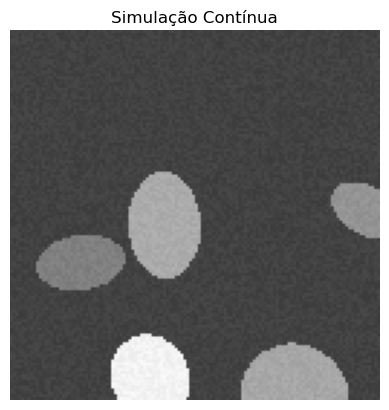

In [3]:
plot_simulation_frames(frames)

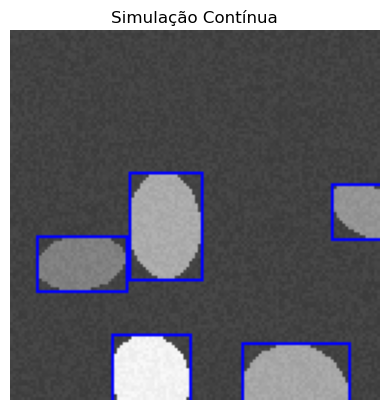

In [4]:
plot_simulation_frames(frames_with_bboxes)

In [5]:
frames_with_noisy_bboxes, noisy_annotations = create_noisy_bboxes(frames, ground_truth, 0.1)

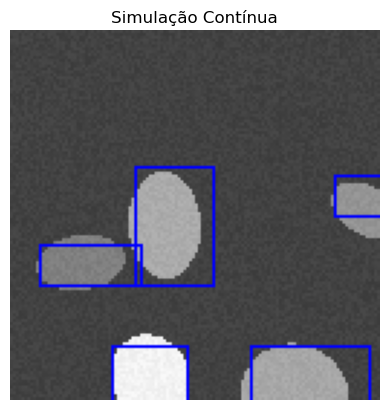

In [6]:
plot_simulation_frames(frames_with_noisy_bboxes)

In [12]:
print("Prints: (IDF1, Switches)")

# Caso (a)
print("IDF1 com predição = ground truth: ", compute_idf1(ground_truth, ground_truth))

# Caso (b)
preds_b = []
frame_k = 23

for linha in ground_truth:
    parts = linha.split(',')
    f = int(float(parts[0]))
    obj_id = int(float(parts[1]))
    
    # A partir do frame k, cruza as identidades 1 e 2
    if f >= frame_k:
        if obj_id == 1:
            parts[1] = '2'
        elif obj_id == 2:
            parts[1] = '1'
            
    preds_b.append(','.join(parts))

print("Duas identidades trocadas a partir do quadro k: ", compute_idf1(ground_truth, preds_b))

# Caso (c)
preds_c = []
frame_k = 30

for linha in ground_truth:
    parts = linha.split(',')
    f = int(float(parts[0]))
    obj_id = int(float(parts[1]))
    
    # A partir do frame k, a elipse 1 muda para um ID inventado
    if f >= frame_k and obj_id == 1:
        parts[1] = '99'
            
    preds_c.append(','.join(parts))

print("Uma track partida em duas no meio: ", compute_idf1(ground_truth, preds_c))

Prints: (IDF1, Switches)
IDF1 com predição = ground truth:  (np.float64(1.0), 0)
Duas identidades trocadas a partir do quadro k:  (np.float64(0.8933333333333333), 2)
Uma track partida em duas no meio:  (np.float64(0.9933333333333333), 1)


# Parte 1

In [95]:
MEAN = [0.485, 0.456, 0.406]
STD  = [0.229, 0.224, 0.225]

def desnorm(img, mean=MEAN, std=STD):
    img_plot = img.cpu().permute(1, 2, 0).numpy()
    mean = np.array(mean)
    std = np.array(std)
    img_plot = (img_plot * std) + mean
    return np.clip(img_plot, 0, 1)

# Pipeline para redimensionamento das imagens
train_transform = A.Compose([
    # # Forca image e mask para 256x256
    # A.Resize(height=256, width=256),

    # # Padroniza o espectro de cores como cinza
    # A.ToGray(p=1.0),

    # # Normaliza os pixels para o padrao ImageNet
    # A.Normalize(mean=MEAN, std=STD),

    # Converte os arrays Numpy para Tensores do PyTorch e ajusta as dimensoes ((H, W, C) ==> (C, H, W))
    ToTensorV2()
])

batch_size = 1


# Definindo as sequências para cada split (exemplo comum de divisão)
# São os números dos vídeos do dataset de treino oficial
train_videos = [2, 4, 5, 9, 10]
val_videos = [11, 13]

# Cria o Dataset de Treino (80% dos vídeos, ordem cronológica perfeita)
train_dataset = MOT17Dataset(
    root="features",
    model_base="SDP",
    sequences_list=train_videos,
    transform=train_transform,
    train_dataset=True
)

# Cria o Dataset de Validação (20% dos vídeos, ordem cronológica perfeita)
val_dataset = MOT17Dataset(
    root="features",
    model_base="SDP",
    sequences_list=val_videos,
    transform=train_transform,
    train_dataset=True  # Mantém True para carregar os GTs para calcular as métricas!
)

# Agora os DataLoaders funcionarão perfeitamente
train_loader = DataLoader(train_dataset, batch_size=1, shuffle=False)
val_loader = DataLoader(val_dataset, batch_size=1, shuffle=False)

In [97]:
current_seq = None

frames = []
ground_truth = []
for batch_idx, (images, dets, gts, seq_names, frame_ids) in enumerate(train_loader):
    # O DataLoader insere uma dimensão extra por causa do batch. Extraímos aqui:
    image = images.squeeze(0)        # Formato final: [3, H, W]
    det = dets.squeeze(0)            # Formato final: [Num_Deteccoes, 5]
    gt = gts.squeeze(0)              # Formato final: [Num_Pessoas_Reais, 4]
    
    seq_name = seq_names[0]          # Extrai a string
    frame_id = frame_ids[0].item()   # Extrai o número do frame
    
    # --- DETECTOR DE MUDANÇA DE VÍDEO ---
    if seq_name != current_seq:
        if not current_seq is None: break
        print(f"\n[{seq_name}] Iniciando processamento do vídeo...")
        current_seq = seq_name
        
        
    frames.append(image.permute(1, 2, 0).numpy())
    gts_str = [
        ', '.join([
            *(row[:-1].int()).numpy().astype(str).tolist(),
            row[-1].numpy().astype(str).tolist()
        ])
        for row in gts[0]
    ]
    ground_truth.extend(gts_str)
    
    # Break de segurança apenas para não rodar tudo
    if batch_idx == 50:
        break


[MOT17-02-SDP] Iniciando processamento do vídeo...


In [98]:
def visualize_ground_truth_RGB(frames, ground_truth):
    # Cria cópias coloridas dos frames para que os retângulos fiquem visíveis 
    # e para não alterar os quadros originais que serão usados pela rede neural
    frames_with_bboxes = [cv2.cvtColor(img.copy(), cv2.COLOR_BGR2RGB) for img in frames]
    
    for annotation in ground_truth:
        # Divide a string da anotação usando a vírgula como separador
        parts = annotation.split(',')
        
        # O MOT17 começa a contar os frames a partir do 1
        # Subtraímos 1 para casar com o índice da lista (que começa em 0)
        f = int(parts[0]) - 1  
        
        # Extrai bb_left, bb_top, bb_width, bb_height
        x = int(parts[2])
        y = int(parts[3])
        w = int(parts[4])
        h = int(parts[5])
        
        # Desenha o retângulo vermelho no frame correspondente
        # cv2.rectangle recebe: imagem, (x_min, y_min), (x_max, y_max), cor (BGR), espessura
        cv2.rectangle(frames_with_bboxes[f], (x, y), (x + w, y + h), (0, 0, 255), 1)
        
    return frames_with_bboxes

In [99]:
frames_with_bboxes = visualize_ground_truth_RGB(frames, ground_truth)

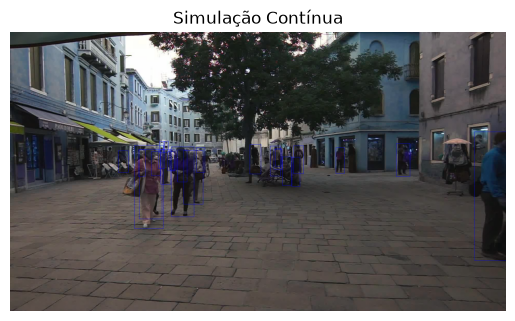

In [101]:
plot_simulation_frames(frames_with_bboxes)